## Overview
The dataset includes 11 clinical features and 1 target variable (HeartDisease):

* **Age**: The patient's age in years.
* **Sex**: Gender of the patient (Male/Female).
* **ChestPainType**: Categorized into four types:
    * **TA**: Typical Angina (chest pain related to heart exertion).
    * **ATA**: Atypical Angina.
    * **NAP**: Non-Anginal Pain (pain not related to the heart).
    * **ASY**: Asymptomatic (no symptoms, but potentially silent heart issues).
* **RestingBP**: Resting blood pressure (in mm Hg).
* **Cholesterol**: Serum cholesterol levels (in mg/dl). High cholesterol is a known risk factor.
* **FastingBS**: Fasting blood sugar. A value of $1$ means the sugar level is $> 120$ mg/dl (indicating potential diabetes), while $0$ is normal.
* **RestingECG**: Results of a resting electrocardiogram (Normal, ST-T wave abnormality, or Left Ventricular Hypertrophy).
* **MaxHR**: The maximum heart rate achieved by the patient during exertion.
* **ExerciseAngina**: Whether the patient experienced chest pain during exercise (Yes/No).
* **Oldpeak**: A numerical value representing "ST depression" on an ECG, which measures heart stress.
* **ST_Slope**: The slope of the ST segment during peak exercise (Up, Flat, or Down).
* **HeartDisease**: THe target variable ($1$ = Heart Disease present, $0$ = Normal).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## Quality control

In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
print("\nZero values count:")
(df == 0).sum()


Zero values count:


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

There are no null values in the dataset, however it does contain some anomialies. 172 entries for Cholesterol and 1 entry for RestingBP are recorded as 0. Since a living person cannot have 0 cholesterol or 0 blood pressure, these are likely missing data points.

Outliers:

* Cholesterol. Some patients have values exceeding  500  mg/dl, which are extreme but medically possible.

* RestingBP. Values go up to  200  mm Hg, indicating severe hypertension.

The dataset is well-balanced, with  55%  of patients having heart disease and  45%  being healthy.

<Axes: xlabel='HeartDisease', ylabel='count'>

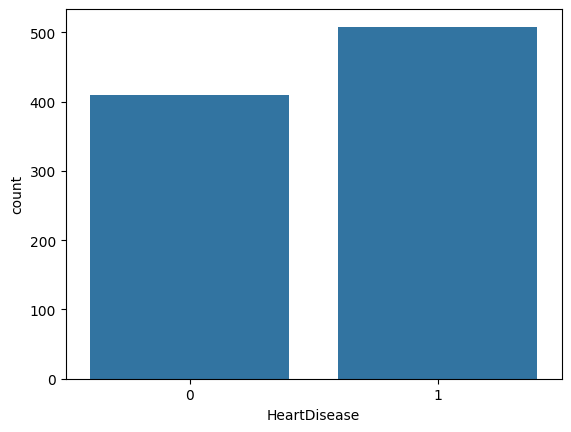

In [7]:
sns.countplot(x='HeartDisease', data=df)

## EDA

### Demographics

Risk increases significantly with age, particularly between 50 and 65. Males are significantly more likely than females to be diagnosed with heart disease in this dataset.

<Axes: xlabel='Age', ylabel='Count'>

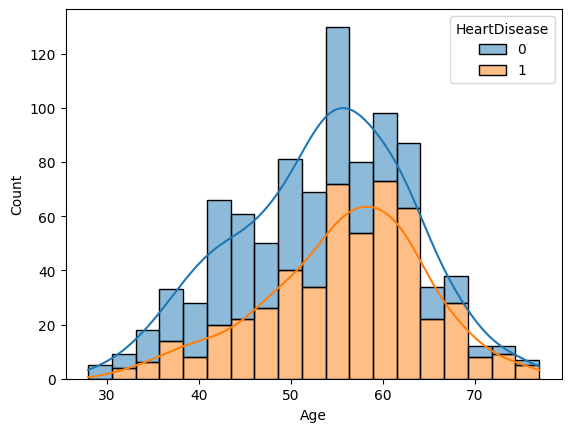

In [8]:
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True, multiple='stack')

### Clinical Indicators

Asymptomatic (ASY) patients are the most likely to have heart disease. Absence of typical pain does not indicate a healthy heart. Atypical Angina (ATA) is most commonly associated with healthy patients. Max heart rate (MaxHR) shows a strong negative correlation (-0.40) with heart disease. Healthy individuals achieve higher maximum heart rates during exercise. Patients with exercise-induced chest pain are highly likely to have heart disease. A Flat or Down slope on an ECG strongly predicts heart disease. An Up slope is typically found in healthy hearts.

<Axes: >

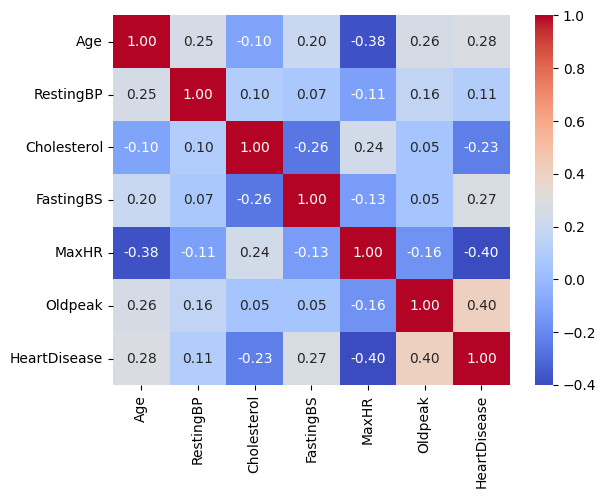

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

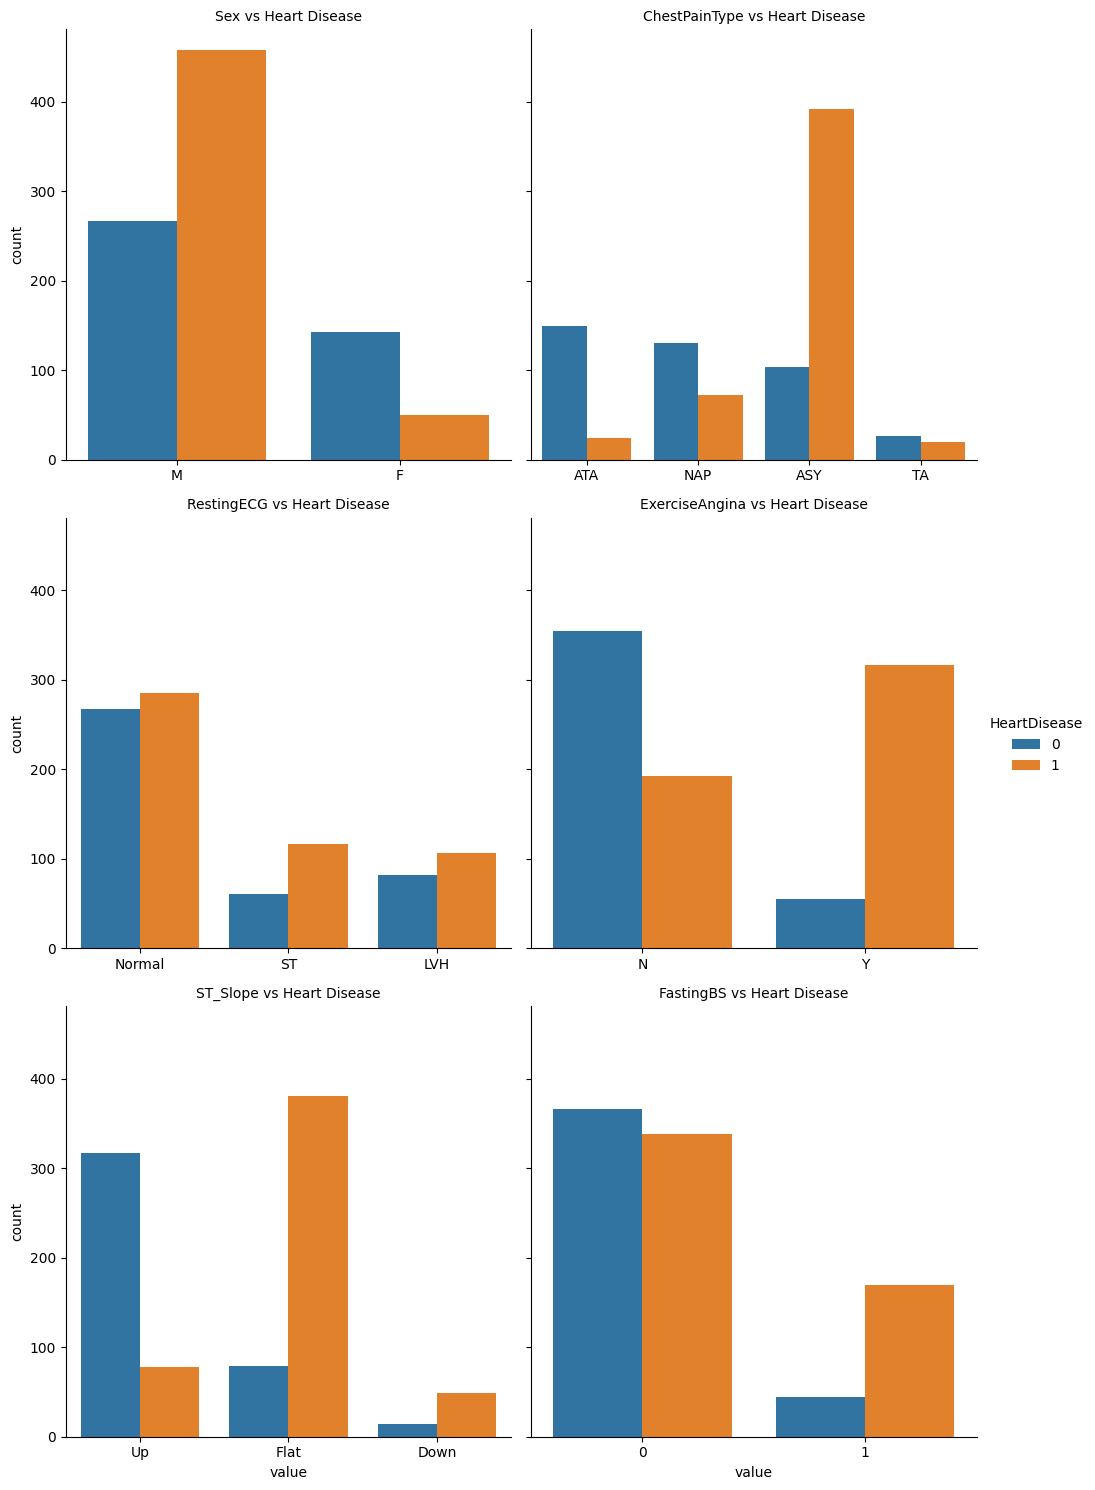

In [36]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
sns.catplot(
    data=df.melt(id_vars='HeartDisease', value_vars=categorical_cols), 
    kind='count', 
    x='value', 
    hue='HeartDisease', 
    col='variable', 
    col_wrap=2, 
    sharex=False
).set_titles("{col_name} vs Heart Disease")

### Bivariate

Maximum heart rate declines with age. Patients with heart disease show lower maximum heart rates than healthy peers of the same age. Patients with high fasting blood sugar (> 120 mg/dl) show a higher frequency of heart disease, confirming diabetes as a comorbid risk factor.

Age               Axes(0.125,0.77;0.168478x0.11)
RestingBP      Axes(0.327174,0.77;0.168478x0.11)
Cholesterol    Axes(0.529348,0.77;0.168478x0.11)
MaxHR          Axes(0.731522,0.77;0.168478x0.11)
Oldpeak          Axes(0.125,0.638;0.168478x0.11)
dtype: object

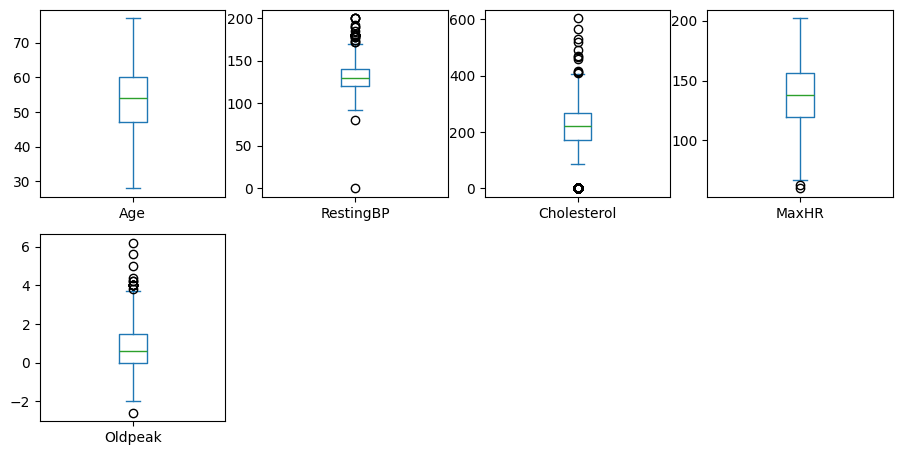

In [34]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[numerical_cols].plot(kind='box', subplots=True, layout=(6, 4), figsize=(11,8.5*2), sharex=False, sharey=False)

Text(0.5, 1.0, 'Age vs MaxHR colored by Heart Disease')

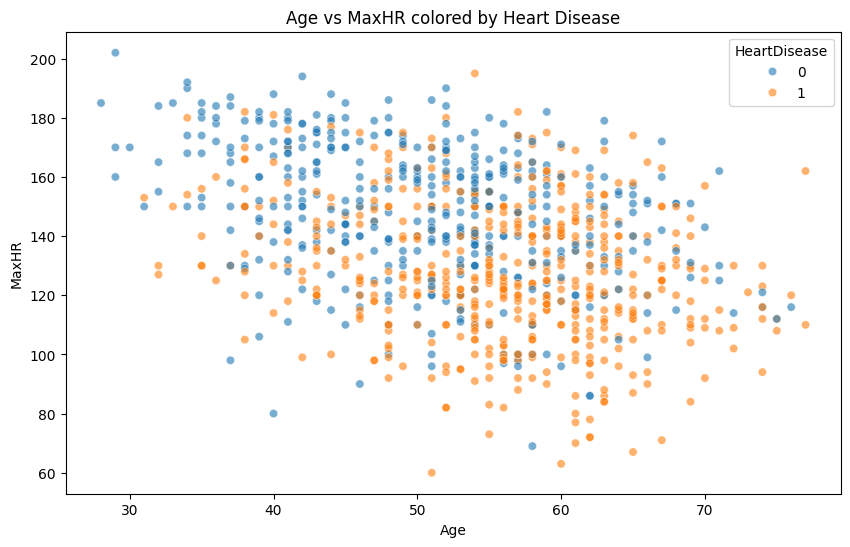

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=df, alpha=0.6)
plt.title('Age vs MaxHR colored by Heart Disease')

### Machine Learning

For building a machine learning model to predict heart failure, several feature engineering steps are recommended. Missing or invalid values in Cholesterol and RestingBP, which appear as zeros, should be replaced with the median value of the dataset. Categorical variables require encoding: ChestPainType, RestingECG, and ST_Slope should be transformed via one-hot encoding into binary columns such as is_ASY or is_Flat, while Sex and ExerciseAngina should be converted into simple binary indicators (1 and 0). Because features like Age, RestingBP, and Cholesterol operate on different numerical scales, normalization or standardization is necessary to improve the performance of algorithms such as Logistic Regression and Support Vector Machines. An interaction feature combining Age and maximum heart rate may be useful because the relationship between these two variables serves as one of the key indicators of cardiovascular fitness.

### Conclusion

The Kaggle Heart Failure dataset identifies Age, Sex, and Exercise-Induced Angina as primary risk factors. The most technical predictors are ECG results, specifically ST Slope and Oldpeak values. Asymptomatic patients often harbor silent heart disease. Clinical tests such as MaxHR and ECG slopes are vital for early detection.